In [1]:
import importlib
import MPI_collective
import MPI
import qiskit
import math
from qiskit import QuantumCircuit, transpile, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import *
importlib.reload(MPI_collective)
importlib.reload(MPI)

<module 'MPI' from '/workspaces/qmpi_cpe_kmutt/QMPI_Tinthai_Version/playground/MPI.py'>

In [90]:
# Function พวกนี้ เราเขียนมาเพื่อให้ใช้งานง่ายขึ้นเฉยๆนะ

def qdata_to_circuit(qc, qdata):
    # for inst, qargs, cargs in qdata:
    #     qc.append(inst, qargs, cargs)
    for instr in qdata:
        qc.append(instr.operation, instr.qubits, instr.clbits)

def beautiful_print_result(qc, counts):
    creg_sequence = []
    for creg in qc.cregs:
        creg_sequence.append(f"{creg.name}[{creg.size}]")
    creg_sequence.reverse()
    print("Classical registers (left→right):", " → ".join(creg_sequence))

    print("\nCounts:")
    for bits, count in counts.items():
        print(f"{bits} : {count}")

def prob_single_cbit(counts, target_index):
    # index ของ cbit ตรงกลาง (จากซ้ายไปขวา)
    total = sum(counts.values())

    p0 = sum(v for k, v in counts.items() if k.split()[target_index] == '0') / total
    p1 = sum(v for k, v in counts.items() if k.split()[target_index] == '1') / total

    print(f"P(cbit[{target_index}] = 0) = {p0:.4f}")
    print(f"P(cbit[{target_index}] = 1) = {p1:.4f}")

def mbu(qq, contain_qbit, uncompute_qbit, creg):
    qq.q.h(uncompute_qbit)
    qq.recieveEPR(qq.q, uncompute_qbit, creg)
    qq.q.barrier(contain_qbit, uncompute_qbit) 
    with qq.q.if_test((creg,1)):
        qq.q.z(contain_qbit)
    qq.q.barrier(contain_qbit, uncompute_qbit)
    return qq

def my_qtp2(qq, src, eprsrc, dsc, srccreg):
    qq.cx(src, eprsrc)
    qq.measure(eprsrc, srccreg)
    qq.h(src)
    qq.reset(eprsrc)
    with qq.if_test((srccreg,1)):
        qq.x(dsc)
    qq.measure(src, srccreg)

    # This barrier is very important
    # Because it can help to do phase correction
    qq.barrier(src, eprsrc, dsc) 

    with qq.if_test((srccreg,1)):
        qq.z(dsc)
    qq.barrier(src, eprsrc, dsc)
    return qq

def weird_function1(qq, eprsrc, dsc, srccreg):
    qq.measure(eprsrc, srccreg)
    qq.reset(eprsrc)
    with qq.if_test((srccreg,1)):
        qq.x(dsc)
    qq.barrier(eprsrc, eprsrc, dsc)
    return qq

def my_copy(qq, src, eprsrc, dsc, srccreg):
    qq.h(eprsrc)
    qq.cx(eprsrc, dsc)
    qq.cx(src, eprsrc)
    qq.measure(eprsrc, srccreg)
    #qq.x(self.EPRdestbit).c_if(self.Csrcbit,1)
    with qq.if_test((srccreg,1)):
        qq.x(dsc)
    qq.barrier()
    return qq

In [104]:
collective_circuit_tinthai = QuantumCircuit()
node0 = QuantumRegister(1, name = "node0")
node1 = QuantumRegister(1, name = "node1")
node2 = QuantumRegister(1, name = "node2")
node3 = QuantumRegister(1, name = "node3")
node0_epr = QuantumRegister(1, name = "node0_epr")
node1_epr = QuantumRegister(1, name = "node1_epr")
node2_epr = QuantumRegister(1, name = "node2_epr")
node3_epr = QuantumRegister(1, name = "node3_epr")
node0_epr_creg = ClassicalRegister(1, name = "node0_epr_creg")
node1_epr_creg = ClassicalRegister(1, name = "node1_epr_creg")
node2_epr_creg = ClassicalRegister(1, name = "node2_epr_creg")
node3_epr_creg = ClassicalRegister(1, name = "node3_epr_creg")

bcast_buffer_epr = QuantumRegister(1, name = "bcast_buffer_epr")
bcast_buffer_epr_creg = ClassicalRegister(1, name = "bcast_buffer_epr_creg")
bcast_device_epr = QuantumRegister(3, name = "bcast_device_epr")
bcast_device_epr_creg = ClassicalRegister(3, name = "bcast_device_epr_creg")
uncompute_creg = ClassicalRegister(1, name = "uncompute_creg")

collective_circuit_tinthai.add_register(node0, node1, node2, node3, node0_epr, node1_epr, node2_epr, node3_epr, bcast_buffer_epr, bcast_device_epr)
collective_circuit_tinthai.add_register(node0_epr_creg, node1_epr_creg, node2_epr_creg, node3_epr_creg, bcast_buffer_epr_creg, bcast_device_epr_creg, uncompute_creg)

# Initiate ให้ node1[0] มีโอกาส ket(0) ~75%
collective_circuit_tinthai.rx(math.pi/4, node0[0])   # หมุนแกน X มุม π/4 บน qubit 0
collective_circuit_tinthai.ry(math.pi/4, node0[0])   # หมุนแกน Y มุม π/4 บน qubit 0

# EPR Pair Preparation
collective_circuit_tinthai.h(bcast_device_epr[0])
collective_circuit_tinthai.h(bcast_device_epr[1])
collective_circuit_tinthai.h(bcast_device_epr[2])
collective_circuit_tinthai.cx(bcast_device_epr[0], node1[0])
collective_circuit_tinthai.cx(bcast_device_epr[1], node2[0])
collective_circuit_tinthai.cx(bcast_device_epr[2], node3[0])
collective_circuit_tinthai.barrier()

# Copy to buffer_epr
collective_circuit_tinthai = my_copy(collective_circuit_tinthai, node0[0], node0_epr[0], bcast_buffer_epr[0], node0_epr_creg[0])

# Device setup
collective_circuit_tinthai.barrier()
collective_circuit_tinthai.cx(bcast_buffer_epr[0], bcast_device_epr[0])
collective_circuit_tinthai.cx(bcast_buffer_epr[0], bcast_device_epr[1])
collective_circuit_tinthai.cx(bcast_buffer_epr[0], bcast_device_epr[2])
collective_circuit_tinthai.h(bcast_buffer_epr[0])
collective_circuit_tinthai.reset(bcast_buffer_epr[0])

# Bcast
collective_circuit_tinthai.barrier()
collective_circuit_tinthai = weird_function1(collective_circuit_tinthai, bcast_device_epr[0], node1_epr[0], bcast_device_epr_creg[0])
collective_circuit_tinthai = weird_function1(collective_circuit_tinthai, bcast_device_epr[1], node2_epr[0], bcast_device_epr_creg[1])
collective_circuit_tinthai = weird_function1(collective_circuit_tinthai, bcast_device_epr[2], node3_epr[0], bcast_device_epr_creg[2])

collective_circuit_tinthai.cx(node1_epr[0], node1[0])
collective_circuit_tinthai.cx(node2_epr[0], node2[0])
collective_circuit_tinthai.cx(node3_epr[0], node3[0])

# การวัดด้วยตัวเอง
collective_circuit_tinthai.barrier()
collective_circuit_tinthai.measure(node0[0], node0_epr_creg[0])
collective_circuit_tinthai.measure(node1[0], node1_epr_creg[0])
collective_circuit_tinthai.measure(node2[0], node2_epr_creg[0])
collective_circuit_tinthai.measure(node3[0], node3_epr_creg[0])

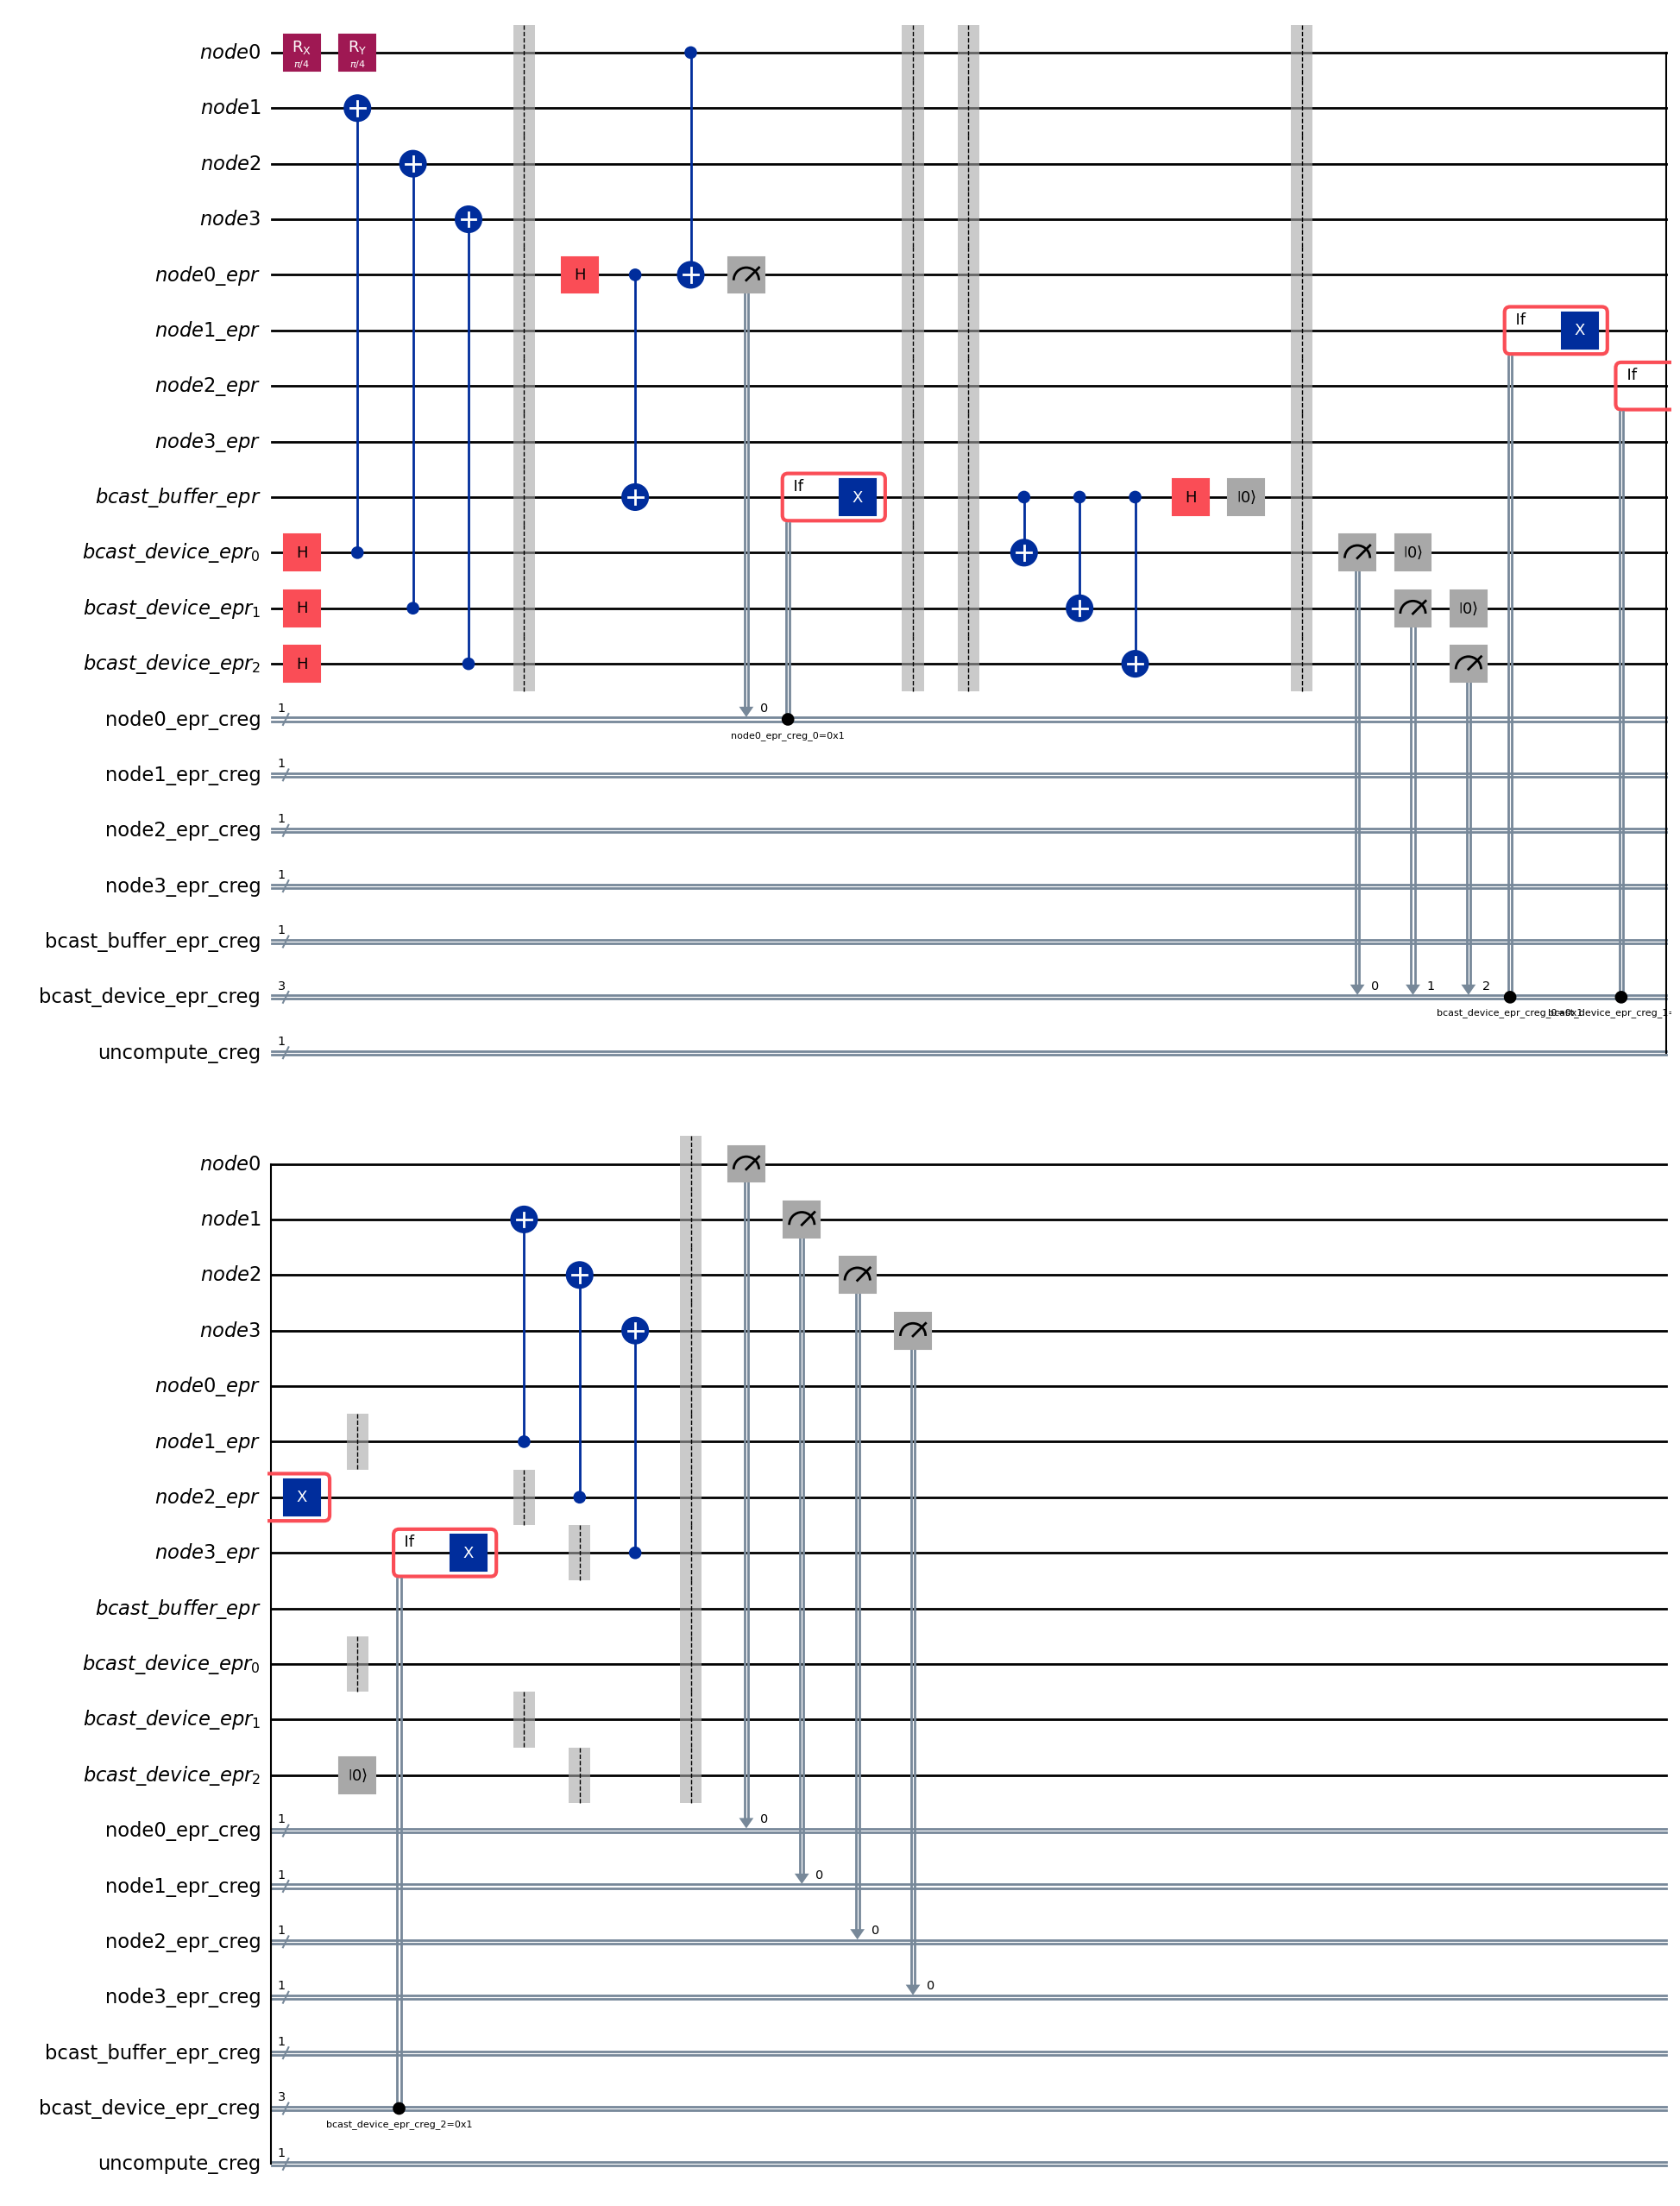

In [105]:
collective_circuit_tinthai.draw("mpl")

In [118]:
sim = FakeKyiv()
collective_circuit_tinthai_ready2rn = transpile(collective_circuit_tinthai, backend=sim, optimization_level=3)
result = sim.run(collective_circuit_tinthai_ready2rn).result()
counts = result.get_counts()
# beautiful_print_result(collective_circuit_tinthai, counts)
# print(counts)
## ถ้าใส่ add_register(c0,c1,c2) ผลลัพธ์จะเป็น 'c2, c1, c0'

print("Node 0 Prob:")
prob_single_cbit(counts, target_index=6)
print("")

print("Node 1 Prob:")
prob_single_cbit(counts, target_index=5)
print("")

print("Node 2 Prob:")
prob_single_cbit(counts, target_index=4)
print("")

print("Node 3 Prob:")
prob_single_cbit(counts, target_index=3)
print("")

Node 0 Prob:
P(cbit[6] = 0) = 0.7773
P(cbit[6] = 1) = 0.2227

Node 1 Prob:
P(cbit[5] = 0) = 0.7393
P(cbit[5] = 1) = 0.2607

Node 2 Prob:
P(cbit[4] = 0) = 0.7285
P(cbit[4] = 1) = 0.2715

Node 3 Prob:
P(cbit[3] = 0) = 0.7246
P(cbit[3] = 1) = 0.2754



In [107]:
from qiskit_aer import AerSimulator
from qiskit import transpile

# 1️⃣ ลบการวัดออก (เพื่อดูสถานะก่อน collapse)
circ_no_measure = collective_circuit_tinthai.remove_final_measurements(inplace=False)

# 2️⃣ บอกให้ simulator เก็บ statevector
circ_no_measure.save_statevector() 

# 3️⃣ ใช้ simulator แบบ statevector
sim_sv = AerSimulator(method='statevector')

# 4️⃣ transpile และรัน
ready_sv = transpile(circ_no_measure, sim_sv)
result_sv = sim_sv.run(ready_sv).result()

# 5️⃣ ดึงข้อมูล statevector ออกมา
statevector = result_sv.data(0)['statevector']
# print(statevector)

In [108]:
from qiskit.quantum_info import Statevector
import numpy as np

# statevector จากผล simulation
vec = Statevector(statevector)

# แสดงเฉพาะค่าสำคัญ
for i, amp in enumerate(vec.data):
    if not np.isclose(abs(amp), 0):  # ข้ามค่าที่แทบเป็นศูนย์
        print(f"|{i:0{vec.num_qubits}b}> : {amp}")

|000011100000> : (0.8535533905932738+0.14644660940672627j)
|000011101111> : (-0.35355339059327384+0.35355339059327384j)


In [111]:
collective_circuit = QuantumCircuit()
nodes_count = 4
qnode = {}
for i in range(nodes_count):
    qnode[i] = QuantumRegister(1, name = f"node{i}")
    collective_circuit.add_register(qnode[i])

# Initiate ให้ node1[0] มีโอกาส ket(0) ~75%
collective_circuit.rx(math.pi/4, qnode[0][0])   # หมุนแกน X มุม π/4 บน qubit 0
collective_circuit.ry(math.pi/4, qnode[0][0])   # หมุนแกน X มุม π/4 บน qubit 0

collective_class_yushi = MPI_collective.CollectiveMPI(collective_circuit)
# collective_class.q.draw('mpl')
# print(collective_class.length)

# Broadcast 
operation = collective_class_yushi.brodcast([qnode[0][0], qnode[1][0], qnode[2][0], qnode[3][0]])

# qdata_to_circuit(collective_class.q, operation)

In [127]:
sim = AerSimulator()
collective_circuit_tinthai_ready2rn = transpile(collective_circuit_tinthai, backend=sim, optimization_level=3)
collective_circuit_yushi_ready2run = transpile(collective_class_yushi.q, backend=sim, optimization_level=3)

In [129]:
bcast_tinthai

[0.16666666666666666, 0.5454545454545454, 0.6470588235294118]

In [1]:
bcast_yushi

NameError: name 'bcast_yushi' is not defined

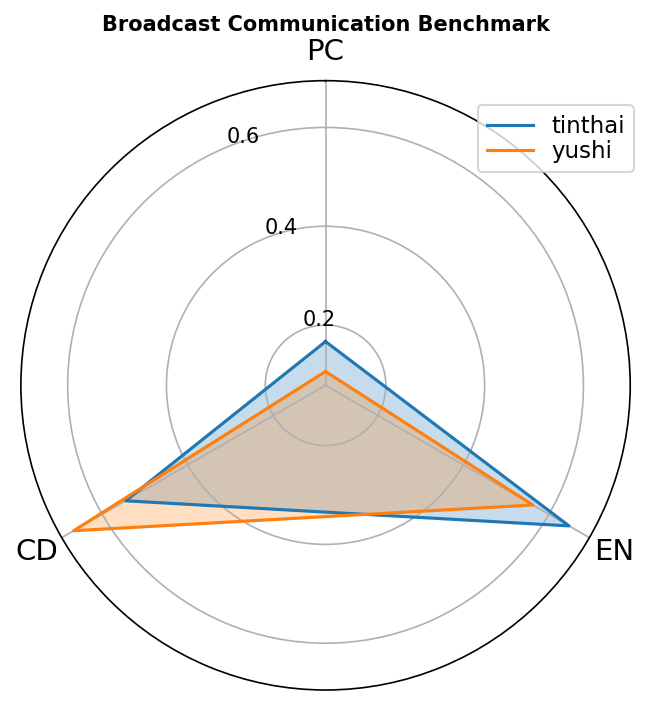

In [128]:
from supermarq import *

bcast_tinthai = [
  converters.compute_communication_with_qiskit(collective_circuit_tinthai_ready2rn),
  converters.compute_depth_with_qiskit(collective_circuit_tinthai_ready2rn),
  converters.compute_entanglement_with_qiskit(collective_circuit_tinthai_ready2rn),
]

bcast_yushi = [
  converters.compute_communication_with_qiskit(collective_circuit_yushi_ready2run),
  converters.compute_depth_with_qiskit(collective_circuit_yushi_ready2run),
  converters.compute_entanglement_with_qiskit(collective_circuit_yushi_ready2run),
]

spoke_labels = ["PC", "CD", "EN"]
plotting.plot_benchmark(
    title= "Broadcast Communication Benchmark",
    labels=["tinthai", "yushi"],             # one label
    features=[bcast_tinthai, bcast_yushi],        # must be a list of feature lists
    spoke_labels=spoke_labels,
    show=True
)